# Task 4: Supervised Learning – Classification Pipeline
**Mục tiêu của notebook này (theo đề bài):**
1. Chọn một **biến mục tiêu dạng phân loại** (discrete categorical label).
2. Kiểm tra **mất cân bằng lớp** (class imbalance) và xử lý bằng `class_weight='balanced'`.
3. Huấn luyện và so sánh 2 mô hình: `LogisticRegression()` và `DecisionTreeClassifier()`.
4. Vẽ **Confusion Matrix (heatmap)** và in đầy đủ `classification_report` (Precision, Recall, Accuracy, F1-Score).
5. Kết luận mô hình nào tốt hơn và đưa ra gợi ý kinh doanh.

## 1. Import thư viện và đọc dữ liệu

In [3]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

sns.set_style('whitegrid')

In [4]:
df = pd.read_csv('eda_completed_master_dataset.csv')
print('Kích thước dữ liệu:', df.shape)
df.head()

Kích thước dữ liệu: (1000, 19)


,OrderID,CustomerID,CustomerName,Age,Gender,City,ProductID,Quantity,TotalAmount,PurchaseDate,PaymentMethod,ProductName,Brand,Category,Price,Rating,Source,Currency,Price_VND_ref
0,ORD00001,C0214,Nguyễn Quốc Khoa,37,Nam,Hải Phòng,P10412,3,57000,2026-01-01,Ví điện tử,Bàn chải đánh răng trẻ em từ 2 đến 6 tuổi P/S ...,P/S,Bàn chải đánh răng,19000.0,4.88,Pharmacity_VN,VND,19000.0
1,ORD00002,C0020,Trần Hữu Thành,18,Nam,Đà Nẵng,P18082,3,123000,2026-01-01,Thẻ ngân hàng,Kem Đánh Răng P/S Chăm Sóc Toàn Diện (tuýp 230g),P/S,Kem đánh răng,41000.0,4.92,Pharmacity_VN,VND,41000.0
2,ORD00003,C0144,Bùi Thị Xuân,32,Nữ,TP. Hồ Chí Minh,P29620,1,194250,2026-01-01,Tiền mặt,Kem Đánh Răng Marvis Jasmin Mint Vị Hoa Nhài &...,Marvis,Kem đánh răng,194250.0,4.87,Pharmacity_VN,VND,194250.0
3,ORD00004,C0253,Nguyễn Minh Huy,51,Nam,Hà Nội,P28349,1,110000,2026-01-02,COD,Nước súc miệng SMC Ag+ vệ sinh răng miệng (Cha...,Unknown,Nước súc miệng,110000.0,4.85,Pharmacity_VN,VND,110000.0
4,ORD00005,C0138,Nguyễn Mỹ Dương,27,Nữ,Cần Thơ,P25083,3,37500,2026-01-02,Tiền mặt,Băng vệ sinh ban ngày siêu mỏng cánh Kotex Gar...,Kotex,Băng vệ sinh,12500.0,4.96,Pharmacity_VN,VND,12500.0


In [5]:
# Kiểm tra nhanh: có giá trị thiếu không?
print(df.isnull().sum().sum(), 'giá trị thiếu trong toàn bộ bảng')
df[['Age', 'Quantity', 'TotalAmount', 'Price', 'Rating']].describe()

0 giá trị thiếu trong toàn bộ bảng


,Age,Quantity,TotalAmount,Price,Rating
count,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000
mean,30.438000,1.887000,1.705447e+05,90244.900000,4.760540
std,8.992609,1.099746,1.839582e+05,69849.774814,0.147201
min,18.000000,1.000000,1.000000e+04,10000.000000,4.500000
25%,23.000000,1.000000,5.700000e+04,38000.000000,4.630000
50%,30.000000,1.500000,1.100000e+05,68000.000000,4.770000
75%,36.000000,3.000000,1.990000e+05,119000.000000,4.880000
max,69.000000,5.000000,1.225000e+06,399200.000000,5.000000


## 2. Chọn biến mục tiêu (Target)

Dữ liệu không có sẵn cột nhãn như "Churn/Active", nên nhóm **tự tạo nhãn** từ cột `TotalAmount` (tổng tiền của đơn hàng):

- **High_Value = 1 (Đơn giá trị cao):** đơn hàng có `TotalAmount` nằm trong **25% cao nhất** (từ phân vị 75 trở lên).
- **High_Value = 0 (Đơn thường):** các đơn còn lại.

**Bài toán:** *Dựa vào thông tin khách hàng và sản phẩm, dự đoán đơn hàng này có phải đơn giá trị cao hay không?*
Doanh nghiệp có thể dùng kết quả này để biết nên tập trung khuyến mãi/combo cho nhóm đơn nào.

Vì `TotalAmount = Price × Quantity`, nếu đưa cả `Price` và `Quantity` vào làm feature thì mô hình chỉ cần nhân hai số
là ra đáp án, không còn là "dự đoán" nữa. Vì vậy ta **không dùng `Price`, `TotalAmount`**  làm feature.

In [6]:
nguong = df['TotalAmount'].quantile(0.75)
print('Ngưỡng đơn giá trị cao (phân vị 75):', f'{nguong:,.0f} VND')

df['High_Value'] = (df['TotalAmount'] >= nguong).astype(int)
df[['TotalAmount', 'High_Value']].head()

Ngưỡng đơn giá trị cao (phân vị 75): 199,000 VND


,TotalAmount,High_Value
0,57000,0
1,123000,0
2,194250,0
3,110000,0
4,37500,0


## 3. Kiểm tra mất cân bằng lớp (Class Imbalance)

Số lượng mỗi lớp:
High_Value
0    748
1    252
Name: count, dtype: int64

Tỷ lệ mỗi lớp (%):
High_Value
0    74.8
1    25.2
Name: proportion, dtype: float64


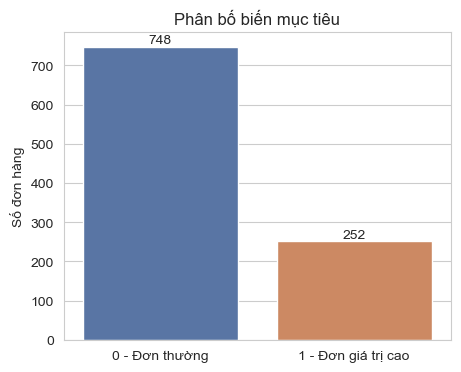

In [7]:
dem = df['High_Value'].value_counts().sort_index()
ty_le = df['High_Value'].value_counts(normalize=True).sort_index() * 100

print('Số lượng mỗi lớp:')
print(dem)
print()
print('Tỷ lệ mỗi lớp (%):')
print(ty_le.round(1))

plt.figure(figsize=(5, 4))
ax = sns.countplot(x='High_Value', data=df, palette=['#4C72B0', '#DD8452'])
ax.set_xticklabels(['0 - Đơn thường', '1 - Đơn giá trị cao'])
ax.set_xlabel('')
ax.set_ylabel('Số đơn hàng')
ax.set_title('Phân bố biến mục tiêu')
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')
plt.show()

**Nhận xét:** Tỷ lệ khoảng **75% – 25%**, tức là dữ liệu **bị mất cân bằng**.
Nếu mô hình chỉ đoán toàn bộ là "Đơn thường" thì vẫn đạt Accuracy ≈ 75% nhưng **không phát hiện được đơn giá trị cao nào**.
Vì vậy:
- Ta dùng `class_weight='balanced'` để mô hình chú ý hơn tới lớp thiểu số (đơn giá trị cao).
- Khi so sánh mô hình, ta **không chỉ nhìn Accuracy** mà còn xem **Recall** và **F1-Score** của lớp "Đơn giá trị cao".

## 4. Khám phá nhanh: yếu tố nào liên quan tới đơn giá trị cao?

Trước khi huấn luyện, ta xem tỷ lệ đơn giá trị cao theo số lượng mua và theo nhóm sản phẩm.

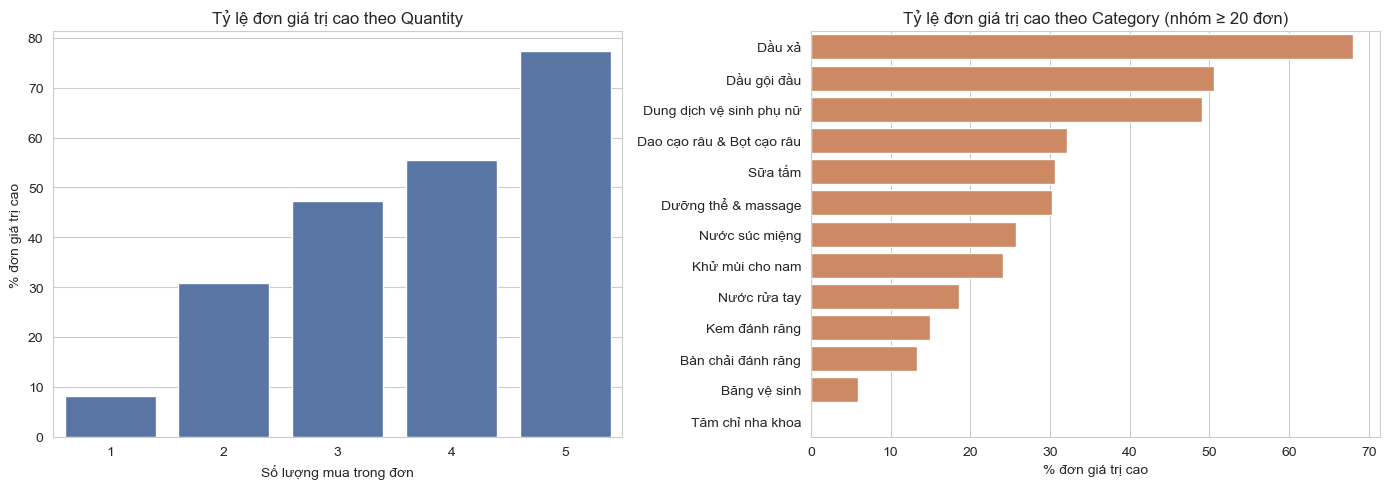

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Theo số lượng mua
tl_qty = df.groupby('Quantity')['High_Value'].mean() * 100
sns.barplot(x=tl_qty.index, y=tl_qty.values, ax=axes[0], color='#4C72B0')
axes[0].set_title('Tỷ lệ đơn giá trị cao theo Quantity')
axes[0].set_xlabel('Số lượng mua trong đơn')
axes[0].set_ylabel('% đơn giá trị cao')

# (b) Theo nhóm sản phẩm (chỉ lấy nhóm có từ 20 đơn trở lên để số liệu đủ tin cậy)
nhom = df.groupby('Category')['High_Value'].agg(['mean', 'count'])
nhom = nhom[nhom['count'] >= 20].sort_values('mean', ascending=False)
sns.barplot(x=nhom['mean'] * 100, y=nhom.index, ax=axes[1], color='#DD8452')
axes[1].set_title('Tỷ lệ đơn giá trị cao theo Category (nhóm ≥ 20 đơn)')
axes[1].set_xlabel('% đơn giá trị cao')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [9]:
# Các biến khách hàng khác (giới tính, thành phố, thanh toán): tỷ lệ có khác nhau nhiều không?
for cot in ['Gender', 'City', 'PaymentMethod']:
    print((df.groupby(cot)['High_Value'].mean() * 100).round(1).to_string())
    print('-' * 30)

Gender
Nam    26.3
Nữ     24.3
------------------------------
City
Cần Thơ            25.5
Hà Nội             23.7
Hải Phòng          24.3
TP. Hồ Chí Minh    26.1
Đà Nẵng            26.6
------------------------------
PaymentMethod
COD              26.9
Thẻ ngân hàng    21.5
Tiền mặt         26.2
Ví điện tử       26.0
------------------------------


**Nhận xét:**
- `Quantity` ảnh hưởng **rất mạnh**: mua càng nhiều sản phẩm trong một đơn thì càng dễ là đơn giá trị cao.
- `Category` cũng có ảnh hưởng rõ (ví dụ nhóm chăm sóc tóc có tỷ lệ cao hơn hẳn băng vệ sinh, tăm chỉ nha khoa).
- `Gender`, `City`, `PaymentMethod` có tỷ lệ gần như giống nhau giữa các nhóm → dự kiến ít đóng góp cho mô hình.

## 5. Chuẩn bị dữ liệu cho mô hình

**Features được chọn:**
- Dạng số: `Age`, `Quantity`, `Rating`
- Dạng chữ (cần chuyển thành số): `Gender`, `City`, `PaymentMethod`, `Category`

Các cột dạng chữ được chuyển thành cột 0/1 bằng **One-Hot Encoding** (`pd.get_dummies`).
Ta dùng `drop_first=True` để bỏ bớt 1 cột mỗi nhóm, tránh các cột bị trùng thông tin.

In [10]:
feature_cols = ['Age', 'Quantity', 'Rating', 'Gender', 'City', 'PaymentMethod', 'Category']

X = pd.get_dummies(df[feature_cols], drop_first=True)
y = df['High_Value']

print('Số feature sau khi One-Hot Encoding:', X.shape[1])
X.head()

Số feature sau khi One-Hot Encoding: 37


,Age,Quantity,Rating,Gender_Nữ,City_Hà Nội,City_Hải Phòng,City_TP. Hồ Chí Minh,City_Đà Nẵng,PaymentMethod_Thẻ ngân hàng,PaymentMethod_Tiền mặt,...,Category_Sáp khử mùi,Category_Sản phẩm chăm sóc răng miệng khác,Category_Sản phẩm tắm & dưỡng thể cho nam,Category_Sản phẩm vệ sinh khác,Category_Sữa tắm,Category_Tã dán,Category_Tăm chỉ nha khoa,Category_Tẩy tế bào chết toàn thân,Category_Xà bông cục,Category_Xịt khử mùi
0,37,3,4.88,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,18,3,4.92,False,False,False,False,True,True,False,...,False,False,False,False,False,False,False,False,False,False
2,32,1,4.87,True,False,False,True,False,False,True,...,False,False,False,False,False,False,False,False,False,False
3,51,1,4.85,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,27,3,4.96,True,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


### 5.1. Chia Train / Test

- Chia **80% train – 20% test**.
- Dùng `stratify=y` để tỷ lệ 75% – 25% được giữ nguyên ở cả tập train và tập test.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train:', X_train.shape, '| Test:', X_test.shape)
print('Tỷ lệ đơn giá trị cao - train: {:.1f}% | test: {:.1f}%'.format(
    y_train.mean() * 100, y_test.mean() * 100))

Train: (800, 37) | Test: (200, 37)
Tỷ lệ đơn giá trị cao - train: 25.2% | test: 25.0%


### 5.2. Chuẩn hóa dữ liệu (chỉ cần cho Logistic Regression)

Logistic Regression nhạy với thang đo (ví dụ `Age` ~ 30 nhưng cột 0/1 chỉ có 0 hoặc 1), nên ta dùng `StandardScaler`.
Cây quyết định thì **không cần** chuẩn hóa.

Lưu ý: chỉ `fit` scaler trên **tập train**, sau đó `transform` cho tập test (để không "nhìn trộm" dữ liệu test).

In [12]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

## 6. Mô hình 1: Logistic Regression

Ta huấn luyện 2 phiên bản để thấy tác dụng của `class_weight='balanced'`:
- Phiên bản A: **không** xử lý mất cân bằng.
- Phiên bản B: **có** `class_weight='balanced'`.

In [13]:
# Phiên bản A: không xử lý mất cân bằng
lr_goc = LogisticRegression(max_iter=1000, random_state=42)
lr_goc.fit(X_train_sc, y_train)
pred_lr_goc = lr_goc.predict(X_test_sc)

print('=== Logistic Regression - KHÔNG dùng class_weight ===')
print(classification_report(y_test, pred_lr_goc, target_names=['Đơn thường', 'Đơn giá trị cao']))

=== Logistic Regression - KHÔNG dùng class_weight ===
                 precision    recall  f1-score   support

     Đơn thường       0.85      0.90      0.87       150
Đơn giá trị cao       0.63      0.52      0.57        50

       accuracy                           0.81       200
      macro avg       0.74      0.71      0.72       200
   weighted avg       0.80      0.81      0.80       200



In [14]:
# Phiên bản B: có class_weight='balanced'
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train_sc, y_train)
pred_lr = lr.predict(X_test_sc)

print('=== Logistic Regression - CÓ class_weight="balanced" ===')
print(classification_report(y_test, pred_lr, target_names=['Đơn thường', 'Đơn giá trị cao']))

=== Logistic Regression - CÓ class_weight="balanced" ===
                 precision    recall  f1-score   support

     Đơn thường       0.92      0.77      0.84       150
Đơn giá trị cao       0.53      0.80      0.64        50

       accuracy                           0.78       200
      macro avg       0.73      0.78      0.74       200
   weighted avg       0.82      0.78      0.79       200



**Nhận xét:** Khi bật `class_weight='balanced'`, **Recall của lớp "Đơn giá trị cao" tăng rõ rệt** (mô hình bắt được nhiều đơn giá trị cao hơn),
đổi lại Precision giảm một chút và Accuracy tổng thể giảm nhẹ. Đây là sự đánh đổi hợp lý khi ta quan tâm tới lớp thiểu số.
Các bước sau sẽ dùng phiên bản B (có `class_weight`).

## 7. Mô hình 2: Decision Tree

Cây quyết định nếu để mọc tự do (không giới hạn độ sâu) sẽ **học thuộc lòng** tập train (overfitting).
Ta thử vài giá trị `max_depth` để xem hiện tượng này.

In [15]:
ket_qua_depth = []
for d in [None, 3, 4, 5, 6]:
    cay = DecisionTreeClassifier(max_depth=d, class_weight='balanced', random_state=42)
    cay.fit(X_train, y_train)
    ket_qua_depth.append({
        'max_depth': 'Không giới hạn' if d is None else d,
        'Accuracy train': round(cay.score(X_train, y_train), 3),
        'Accuracy test': round(cay.score(X_test, y_test), 3),
    })

pd.DataFrame(ket_qua_depth)

,max_depth,Accuracy train,Accuracy test
0,Không giới hạn,1.000,0.715
1,3,0.735,0.720
2,4,0.764,0.705
3,5,0.801,0.725
4,6,0.815,0.730


**Nhận xét:** Khi không giới hạn độ sâu, Accuracy trên train là 1.0 (học thuộc lòng) nhưng trên test chỉ khoảng 0.72 → khoảng cách rất lớn, đây là dấu hiệu **overfitting**.
Các độ sâu từ 3 đến 6 cho Accuracy test gần như nhau, nên nhóm chọn **`max_depth=4`** vì cây đủ đơn giản để vẽ ra và đọc hiểu được.

In [16]:
dt = DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42)
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)

print('=== Decision Tree (max_depth=4, class_weight="balanced") ===')
print(classification_report(y_test, pred_dt, target_names=['Đơn thường', 'Đơn giá trị cao']))

=== Decision Tree (max_depth=4, class_weight="balanced") ===
                 precision    recall  f1-score   support

     Đơn thường       0.94      0.65      0.77       150
Đơn giá trị cao       0.45      0.88      0.60        50

       accuracy                           0.70       200
      macro avg       0.70      0.76      0.68       200
   weighted avg       0.82      0.70      0.72       200



## 8. Confusion Matrix (heatmap)

Cách đọc ma trận (hàng = thực tế, cột = dự đoán):

| | Dự đoán: Đơn thường | Dự đoán: Đơn giá trị cao |
|---|---|---|
| **Thực tế: Đơn thường** | Đúng (TN) | Báo nhầm (FP) |
| **Thực tế: Đơn giá trị cao** | Bỏ sót (FN) | Đúng (TP) |

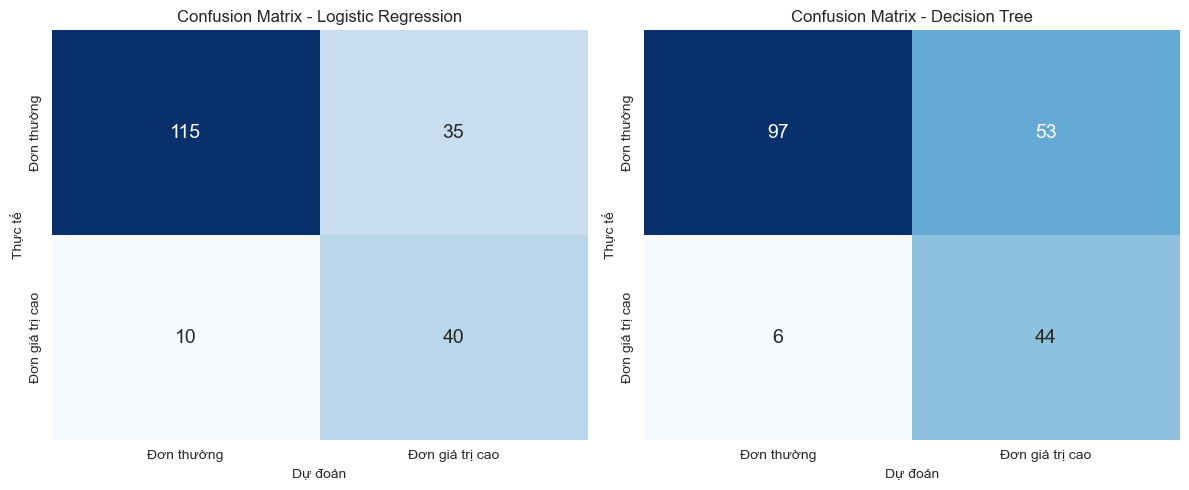

In [17]:
nhan = ['Đơn thường', 'Đơn giá trị cao']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, pred, ten in zip(axes, [pred_lr, pred_dt], ['Logistic Regression', 'Decision Tree']):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=nhan, yticklabels=nhan, ax=ax, annot_kws={'size': 14})
    ax.set_title(f'Confusion Matrix - {ten}')
    ax.set_xlabel('Dự đoán')
    ax.set_ylabel('Thực tế')

plt.tight_layout()
plt.show()

## 9. So sánh hai mô hình

Vì dữ liệu mất cân bằng, ta so sánh dựa trên các chỉ số của **lớp "Đơn giá trị cao"** (Precision, Recall, F1) cùng với Accuracy.
Chỉ số **F1-Score của lớp "Đơn giá trị cao"** được dùng làm tiêu chí chính để chọn mô hình thắng,
vì nó cân bằng giữa việc bắt được nhiều đơn giá trị cao (Recall) và hạn chế báo nhầm (Precision).

In [18]:
def tinh_chi_so(ten, y_that, y_du_doan):
    return {
        'Mô hình': ten,
        'Accuracy': accuracy_score(y_that, y_du_doan),
        'Precision (Cao)': precision_score(y_that, y_du_doan),
        'Recall (Cao)': recall_score(y_that, y_du_doan),
        'F1 (Cao)': f1_score(y_that, y_du_doan),
    }

bang_so_sanh = pd.DataFrame([
    tinh_chi_so('Logistic Regression', y_test, pred_lr),
    tinh_chi_so('Decision Tree', y_test, pred_dt),
]).set_index('Mô hình').round(3)

bang_so_sanh

,Accuracy,Precision (Cao),Recall (Cao),F1 (Cao)
Mô hình,,,,
Logistic Regression,0.775,0.533,0.80,0.640
Decision Tree,0.705,0.454,0.88,0.599


Mô hình thắng (dựa trên F1 của lớp "Đơn giá trị cao"): Logistic Regression


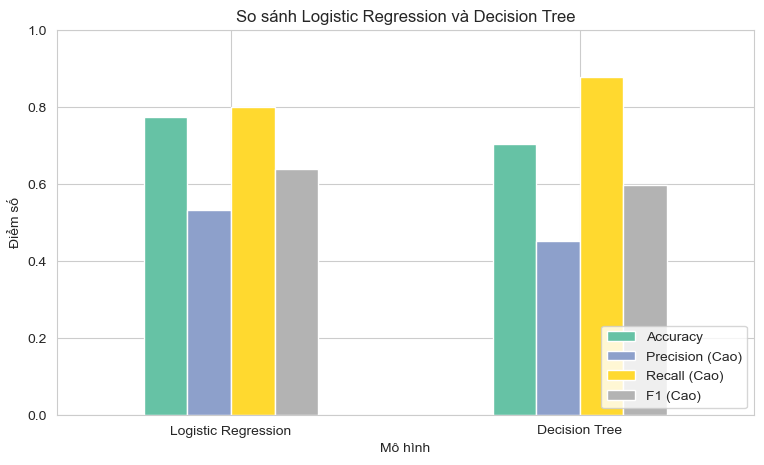

In [19]:
mo_hinh_thang = bang_so_sanh['F1 (Cao)'].idxmax()
print('Mô hình thắng (dựa trên F1 của lớp "Đơn giá trị cao"):', mo_hinh_thang)

bang_so_sanh.plot(kind='bar', figsize=(9, 5), rot=0, colormap='Set2')
plt.title('So sánh Logistic Regression và Decision Tree')
plt.ylabel('Điểm số')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.show()

### Kết luận so sánh (với `random_state=42`)

| Chỉ số | Logistic Regression | Decision Tree |
|---|---|---|
| Accuracy | ≈ 0.78 | ≈ 0.70 |
| Precision (đơn giá trị cao) | ≈ 0.53 | ≈ 0.45 |
| Recall (đơn giá trị cao) | ≈ 0.80 | ≈ 0.88 |
| F1 (đơn giá trị cao) | ≈ 0.64 | ≈ 0.60 |

- **Logistic Regression thắng** vì có Accuracy, Precision và F1-Score cao hơn.
- Decision Tree có Recall cao hơn (bắt được nhiều đơn giá trị cao hơn) nhưng **báo nhầm quá nhiều** (nhiều đơn thường bị đoán thành đơn giá trị cao), nên Precision và Accuracy thấp hơn.
- Cần nhớ: nếu luôn đoán "Đơn thường" thì Accuracy đã là 75%, nên Accuracy 78% chỉ hơn mức này một chút. Giá trị thực của mô hình nằm ở việc nó **phát hiện được khoảng 80% đơn giá trị cao**.
- Mô hình chưa quá mạnh vì các thông tin khách hàng (tuổi, thành phố, giới tính, thanh toán) gần như không liên quan tới giá trị đơn hàng (đã thấy ở mục 4). Hầu hết sức mạnh dự đoán đến từ `Quantity` và `Category`.

*(Các số trên lấy từ lần chạy của nhóm; nếu máy bạn ra số hơi khác, hãy cập nhật lại theo bảng ở trên.)*

## 10. Feature nào quan trọng nhất?

- **Logistic Regression:** xem hệ số (coefficient). Hệ số dương lớn → làm tăng khả năng là đơn giá trị cao; hệ số âm → làm giảm.
- **Decision Tree:** xem `feature_importances_` (feature nào được dùng nhiều để chia nhánh).

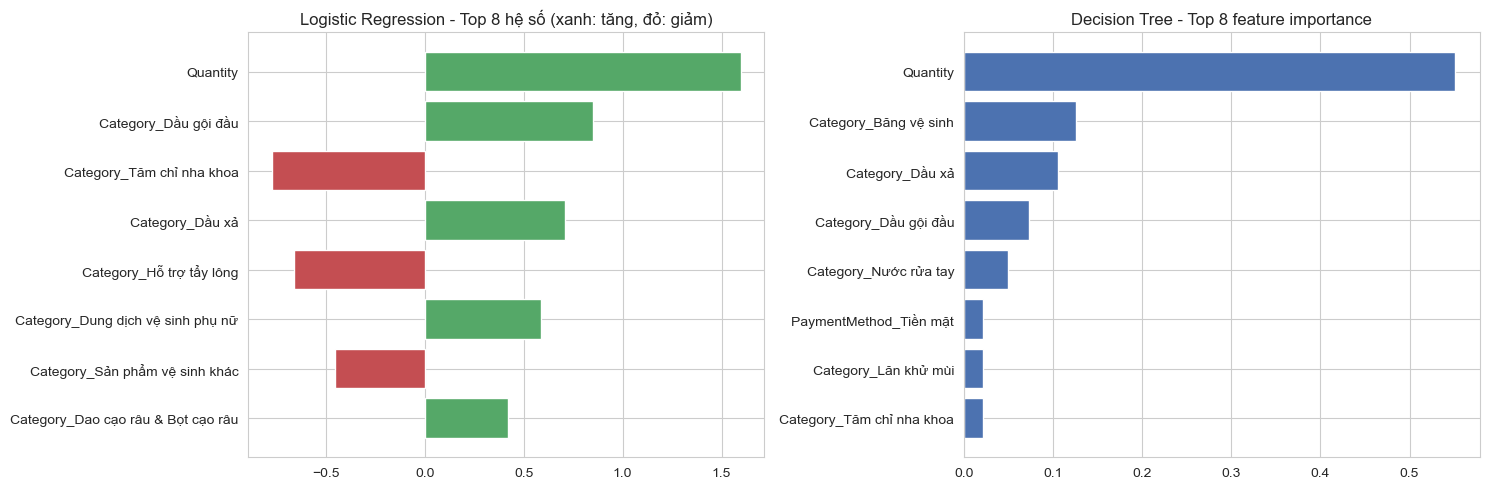

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Logistic Regression: lấy 8 hệ số có độ lớn lớn nhất
he_so = pd.Series(lr.coef_[0], index=X.columns)
top_lr = he_so.reindex(he_so.abs().sort_values(ascending=False).head(8).index)
mau = ['#55A868' if v > 0 else '#C44E52' for v in top_lr.values]
axes[0].barh(top_lr.index[::-1], top_lr.values[::-1], color=mau[::-1])
axes[0].set_title('Logistic Regression - Top 8 hệ số (xanh: tăng, đỏ: giảm)')

# Decision Tree: 8 feature quan trọng nhất
quan_trong = pd.Series(dt.feature_importances_, index=X.columns).sort_values(ascending=False).head(8)
axes[1].barh(quan_trong.index[::-1], quan_trong.values[::-1], color='#4C72B0')
axes[1].set_title('Decision Tree - Top 8 feature importance')

plt.tight_layout()
plt.show()

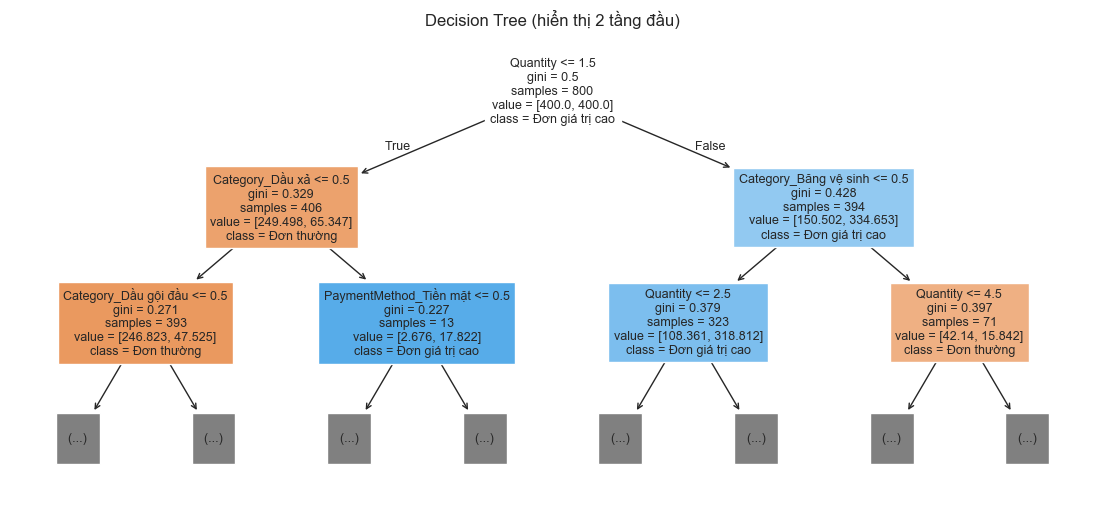

In [21]:
# Vẽ 2 tầng đầu của cây để dễ đọc
plt.figure(figsize=(14, 6))
plot_tree(dt, feature_names=X.columns, class_names=['Đơn thường', 'Đơn giá trị cao'],
          max_depth=2, filled=True, fontsize=9)
plt.title('Decision Tree (hiển thị 2 tầng đầu)')
plt.show()

**Nhận xét:** Ở cả hai mô hình, `Quantity` là feature quan trọng nhất, tiếp theo là một số nhóm sản phẩm (`Category`).
Các feature về khách hàng (giới tính, thành phố, thanh toán) đóng góp rất ít.

## 11. Đề xuất kinh doanh (dựa trên dữ liệu)

1. **Khuyến khích mua nhiều sản phẩm trong một đơn.** Đơn mua 1 sản phẩm chỉ có khoảng 8% là đơn giá trị cao, trong khi đơn mua từ 3 sản phẩm trở lên là khoảng 47% – 77%.
   Pharmacity nên triển khai combo (mua 2 giảm giá, mua 3 tặng quà) hoặc ngưỡng miễn phí vận chuyển để kéo khách tăng số lượng.
2. **Tập trung upsell ở nhóm chăm sóc tóc và vệ sinh phụ nữ.** Các nhóm Dầu xả, Dầu gội đầu, Dung dịch vệ sinh phụ nữ có tỷ lệ đơn giá trị cao khoảng 49% – 68%.
   Nên gợi ý combo "dầu gội + dầu xả" hoặc đưa các sản phẩm này lên vị trí nổi bật.
   Ngược lại, Băng vệ sinh có rất nhiều đơn (186 đơn) nhưng chỉ khoảng 6% là đơn giá trị cao: đây là nhóm kéo lượng khách, có thể dùng để **bán kèm** sản phẩm giá trị cao hơn.
3. **Không cần chia chiến dịch theo giới tính, thành phố hay hình thức thanh toán.** Tỷ lệ đơn giá trị cao giữa các nhóm này gần như bằng nhau (khoảng 24% – 27%),
   nên nguồn lực marketing nên đặt vào **hành vi mua (số lượng, nhóm sản phẩm)** thay vì đặc điểm nhân khẩu học.

*Lưu ý: dữ liệu giao dịch của nhóm là dữ liệu mô phỏng nên các kết luận mang tính minh họa cho bài học.*

## 12. Lưu mô hình 

In [ ]:
if mo_hinh_thang == 'Logistic Regression':
    mo_hinh_tot_nhat, dung_scaler = lr, True
else:
    mo_hinh_tot_nhat, dung_scaler = dt, False

joblib.dump({
    'model': mo_hinh_tot_nhat,
    'scaler': scaler,
    'use_scaler': dung_scaler,
    'columns': list(X.columns),
    'threshold_vnd': float(nguong),
}, 'model/classification_model.pkl')

print('Đã lưu mô hình:', mo_hinh_thang, '-> best_classification_model.pkl')

Đã lưu mô hình: Logistic Regression -> best_classification_model.pkl


## 13. Tóm tắt

- **Bài toán:** phân loại đơn hàng thành *Đơn giá trị cao* (top 25% `TotalAmount`) và *Đơn thường*.
- **Xử lý mất cân bằng:** dữ liệu 75% – 25%, dùng `class_weight='balanced'` → Recall của lớp thiểu số tăng rõ rệt.
- **Mô hình thắng:** Logistic Regression (F1 của lớp "Đơn giá trị cao" cao hơn Decision Tree).
- **Yếu tố ảnh hưởng chính:** số lượng mua (`Quantity`) và nhóm sản phẩm (`Category`).
- **Đã lưu** `best_classification_model.pkl` để dùng cho Task 5.